
####################################################################################################
Running experiment for delay delta = 0.2
####################################################################################################
>>> Training PG (Algo 1)... delta=0.2
200th epoch LSTM-DPO loss: -2.080688
400th epoch LSTM-DPO loss: -2.072256
600th epoch LSTM-DPO loss: -2.089049
800th epoch LSTM-DPO loss: -2.073395
1000th epoch LSTM-DPO loss: -2.071891
1200th epoch LSTM-DPO loss: -2.068988
1400th epoch LSTM-DPO loss: -2.078206
1600th epoch LSTM-DPO loss: -2.052326
1800th epoch LSTM-DPO loss: -2.092048
2000th epoch LSTM-DPO loss: -2.081713
>>> Computing PGDPO (Algo 2)... delta=0.2
>>> Training FABSDE (Algo 3)... delta=0.2
500th epoch Deep ABSDE loss: 0.007040
1000th epoch Deep ABSDE loss: 0.005299
1500th epoch Deep ABSDE loss: 0.003906
2000th epoch Deep ABSDE loss: 0.001695
2500th epoch Deep ABSDE loss: 0.000655
3000th epoch Deep ABSDE loss: 0.000294
3500th epoch Deep ABSDE l

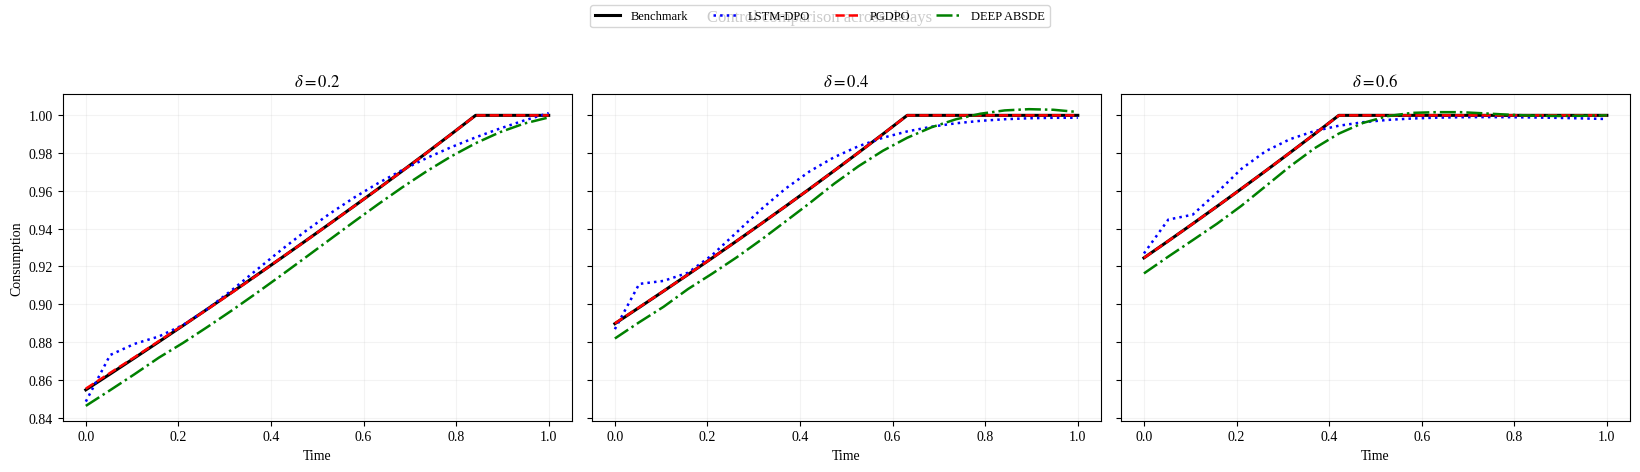

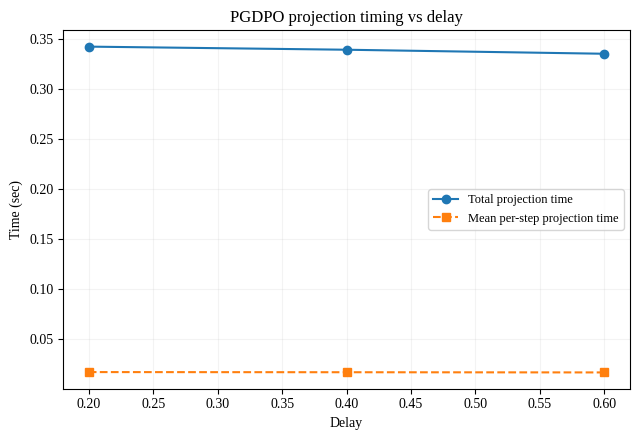

In [ ]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})

# =============================================================================
# 0. Unified Configuration
# =============================================================================
CFG = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float64,

    # problem params
    "alpha": 0.1,
    "beta": 0.2,
    "gamma": 0.5,
    "k_terminal": 1.0,
    "T": 1.0,
    "N": 20,
    "delta": 0.4,
    "delta_list": [0.2, 0.4, 0.6],
    "X0": 1.0,

    # training params (shared)
    "train_paths": 256,
    "hidden": 64,
    "lr": 3e-4,

    # iterations
    "n_iters": 2000,
    "fabsde_iters": 5000,

    # PGDPO projection inner MC
    "proj_inner_mc": 8192,
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


# =============================================================================
# 1. Physics (Dynamics / Utility)
# =============================================================================
class Physics:
    """Shared physics dynamics and utilities."""

    def __init__(self, cfg: dict):
        self.alpha = cfg["alpha"]
        self.beta = cfg["beta"]
        self.gamma = cfg["gamma"]
        self.k_term = cfg["k_terminal"]

        self.h = cfg["T"] / cfg["N"]
        raw_delay_steps = cfg["delta"] / self.h
        rounded_delay_steps = int(round(raw_delay_steps))

        if not np.isclose(raw_delay_steps, rounded_delay_steps, atol=1e-10):
            raise ValueError(
                f"delta={cfg['delta']} is not aligned with h={self.h}. "
                f"Need delta/h to be (approximately) an integer."
            )

        self.delay_steps = rounded_delay_steps

    def step(self, x_now, x_lag, u, dW):
        drift = self.alpha * x_lag - u
        diff = self.beta * x_lag
        return x_now + drift * self.h + diff * dW

    def utility(self, u):
        return (u ** self.gamma) / self.gamma

    def get_terminal_reward(self, x_final):
        return self.k_term * x_final

    def init_history(self, batch_size: int, x0: float):
        return [
            torch.full((batch_size,), x0, device=DEVICE)
            for _ in range(self.delay_steps + 1)
        ]


# =============================================================================
# 2. Models
# =============================================================================
class BaseLSTM(nn.Module):
    def __init__(self, output_dim: int, hidden_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(3, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, t, x, x_lag, hidden):
        inp = torch.stack([t, x, x_lag], dim=1).unsqueeze(1)  # (B,1,3)
        out, new_hidden = self.lstm(inp, hidden)
        return self.fc(out[:, -1, :]), new_hidden


class PolicyNet(nn.Module):
    """
    LSTM-DPO / PGDPO policy without explicit x_lag input.

    Policy input:
        (t, x_now)

    Dynamics still uses x_lag through phy.step(...).
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, t, x, hidden):
        inp = torch.stack([t, x], dim=1).unsqueeze(1)  # (B, 1, 2)
        out, h_new = self.lstm(inp, hidden)
        raw = self.fc(out[:, -1, :])
        return torch.nn.functional.softplus(raw).squeeze(-1), h_new


class FABSDE_Net(BaseLSTM):
    def __init__(self, hidden_dim):
        super().__init__(output_dim=4, hidden_dim=hidden_dim)  # Y, Z, EY, EZ

    def forward(self, t, x, x_lag, hidden):
        raw, new_hidden = super().forward(t, x, x_lag, hidden)
        Y = torch.nn.functional.softplus(raw[:, 0]) + 1e-6
        Z = raw[:, 1]
        EY = torch.nn.functional.softplus(raw[:, 2]) + 1e-6
        EZ = raw[:, 3]
        return Y, Z, EY, EZ, new_hidden


# =============================================================================
# 3. Benchmark Solvers
# =============================================================================
def solve_analytic(cfg):
    phy = Physics(cfg)
    p = np.zeros(cfg["N"] + 1)
    p[cfg["N"] - phy.delay_steps:] = cfg["k_terminal"]

    for i in range(cfg["N"] - phy.delay_steps - 1, -1, -1):
        p[i] = p[i + 1] + cfg["alpha"] * phy.h * p[i + 1 + phy.delay_steps]

    c_star = np.maximum(p, 1e-12) ** (1.0 / (cfg["gamma"] - 1.0))
    return c_star, p


def train_pg(policy: nn.Module, phy: Physics, cfg: dict):
    print(f">>> Training PG (Algo 1)... delta={cfg['delta']}")
    opt = optim.Adam(policy.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["n_iters"] + 1):
        opt.zero_grad()

        dW = torch.randn(cfg["train_paths"], cfg["N"], device=DEVICE) * np.sqrt(phy.h)
        X = torch.zeros(cfg["train_paths"], cfg["N"] + phy.delay_steps + 1, device=DEVICE)
        X[:, : phy.delay_steps + 1] = cfg["X0"]

        run_util = 0.0
        hidden = None

        for n in range(cfg["N"]):
            k = phy.delay_steps + n
            t_val = torch.full((cfg["train_paths"],), n * phy.h, device=DEVICE)

            x_now = X[:, k]
            x_lag = X[:, n]

            # Policy receives only current state x_now.
            c_n, hidden = policy(t_val, x_now, hidden)

            # Dynamics still uses x_lag.
            X[:, k + 1] = phy.step(x_now, x_lag, c_n, dW[:, n])
            run_util += phy.utility(c_n) * phy.h

        loss = -(run_util + phy.get_terminal_reward(X[:, -1])).mean()

        if it % 200 == 0:
            print(f"{it}th epoch LSTM-DPO loss: {loss.item():.6f}")

        loss.backward()
        opt.step()

    return policy

def sample_antithetic_dW(batch_size: int, h: float, device=DEVICE):
    """
    Antithetic Brownian increments with shape (batch_size,).

    If batch_size is even:
        [eps_1, ..., eps_m, -eps_1, ..., -eps_m]

    If batch_size is odd:
        one extra independent draw is appended.
    """
    half = batch_size // 2
    scale = np.sqrt(h)

    eps_half = torch.randn(half, device=device) * scale
    dW = torch.cat([eps_half, -eps_half], dim=0)

    if batch_size % 2 == 1:
        extra = torch.randn(1, device=device) * scale
        dW = torch.cat([dW, extra], dim=0)

    return dW

def compute_ppgdpo(base_policy: nn.Module, phy: Physics, cfg: dict):
    print(f">>> Computing PGDPO (Algo 2)... delta={cfg['delta']}")
    c_proj, p_proj = [], []
    per_step_times = []

    # deterministic realized state history
    real_hist = [torch.tensor([cfg["X0"]], device=DEVICE) for _ in range(phy.delay_steps + 1)]

    # real_hidden_hist[i] = hidden state available at the beginning of decision step i
    real_hidden_hist = [None]

    def _clone_hidden(hidden):
        if hidden is None:
            return None
        h, c = hidden
        return (h.detach().clone(), c.detach().clone())

    def _expand_hidden(hidden, batch_size: int):
        if hidden is None:
            return None
        h, c = hidden
        h = h.expand(-1, batch_size, -1).contiguous()
        c = c.expand(-1, batch_size, -1).contiguous()
        return (h, c)

    hidden_real = None
    total_proj_t0 = time.time()

    for i in range(cfg["N"]):
        step_t0 = time.time()

        x_start = real_hist[-1].detach().clone().requires_grad_(True)
        n_inner = cfg["proj_inner_mc"]

        # stored hidden for current decision step i
        hidden_prefix = real_hidden_hist[i]
        hidden_inner = _expand_hidden(hidden_prefix, n_inner)

        # past state history for projection rollout
        past_hist = torch.stack(real_hist[:-1]).detach()
        past_hist = past_hist[-phy.delay_steps:]          # (delay_steps, 1)
        past_hist = past_hist.expand(-1, n_inner)         # (delay_steps, n_inner)

        curr_state = x_start.expand(n_inner)
        inner_X = [past_hist[k] for k in range(phy.delay_steps)] + [curr_state]

        J_future = 0.0

        for step in range(cfg["N"] - i):
            abs_step = i + step
            k_idx = phy.delay_steps + step
            t_val = torch.full((n_inner,), abs_step * phy.h, device=DEVICE)

            x_now = inner_X[k_idx]
            x_lag = inner_X[step]

            # Policy receives only current state x_now.
            c_val, hidden_inner = base_policy(t_val, x_now, hidden_inner)

            # Dynamics still uses x_lag, with antithetic Brownian increments.
            dW = sample_antithetic_dW(n_inner, phy.h, device=DEVICE)
            x_next = phy.step(x_now, x_lag, c_val, dW)

            inner_X.append(x_next)
            J_future += phy.utility(c_val) * phy.h

        J_total = J_future + phy.get_terminal_reward(inner_X[-1])
        grads = torch.autograd.grad(J_total.sum(), x_start)
        p_t = grads[0].item() / n_inner

        p_clamped = max(p_t, 1e-12)
        c_star = p_clamped ** (1.0 / (cfg["gamma"] - 1.0))

        c_proj.append(c_star)
        p_proj.append(p_t)

        # deterministic real rollout update
        x_now_real = real_hist[-1]
        x_lag_real = real_hist[-(phy.delay_steps + 1)]

        # update hidden history along the realized input stream
        t_real = torch.tensor([i * phy.h], device=DEVICE)

        with torch.no_grad():
            # Hidden state is updated using only current state.
            _, hidden_real = base_policy(t_real, x_now_real, hidden_real)

        x_next_real = phy.step(
            x_now_real,
            x_lag_real,
            torch.tensor([c_star], device=DEVICE),
            0.0,
        )

        real_hist.append(x_next_real)
        real_hidden_hist.append(_clone_hidden(hidden_real))

        step_elapsed = time.time() - step_t0
        per_step_times.append(step_elapsed)

    total_proj_elapsed = time.time() - total_proj_t0

    timing_info = {
        "projection_total_sec": total_proj_elapsed,
        "projection_mean_per_step_sec": float(np.mean(per_step_times)),
        "projection_std_per_step_sec": float(np.std(per_step_times)),
        "projection_per_step_sec": np.array(per_step_times),
    }

    return np.array(c_proj), np.array(p_proj), timing_info


def train_fabsde(phy: Physics, cfg: dict):
    print(f">>> Training FABSDE (Algo 3)... delta={cfg['delta']}")
    net = FABSDE_Net(hidden_dim=cfg["hidden"]).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["fabsde_iters"] + 1):
        opt.zero_grad()

        B = cfg["train_paths"]
        dW = torch.randn(B, cfg["N"], device=DEVICE) * np.sqrt(phy.h)
        X = phy.init_history(B, cfg["X0"])

        preds = {"Y": [], "Z": [], "EY": [], "EZ": []}
        tildeY = [None] * (cfg["N"] + 1)
        hidden = None

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_i = torch.full((B,), i * phy.h, device=DEVICE)

            Y, Z, EY, EZ, hidden = net(t_i, X[k], X[i], hidden)
            preds["Y"].append(Y)
            preds["Z"].append(Z)
            preds["EY"].append(EY)
            preds["EZ"].append(EZ)

            c_i = Y.pow(1.0 / (cfg["gamma"] - 1.0))
            X.append(phy.step(X[k], X[i], c_i, dW[:, i]))

            f_i = (cfg["alpha"] * EY + cfg["beta"] * EZ) if i <= cfg["N"] - phy.delay_steps else torch.zeros_like(Y)
            tildeY[i + 1] = Y - f_i * phy.h + Z * dW[:, i]

        t_N = torch.full((B,), cfg["N"] * phy.h, device=DEVICE)
        Y_N, Z_N, EY_N, EZ_N, _ = net(t_N, X[-1], X[cfg["N"]], hidden)
        preds["Y"].append(Y_N)
        preds["Z"].append(Z_N)
        preds["EY"].append(EY_N)
        preds["EZ"].append(EZ_N)

        L1 = sum((preds["Y"][i + 1] - tildeY[i + 1]).pow(2).mean() for i in range(cfg["N"]))
        L1 += (preds["Y"][cfg["N"]] - cfg["k_terminal"]).pow(2).mean()

        L2 = 0.0
        if phy.delay_steps <= cfg["N"]:
            limit = cfg["N"] - phy.delay_steps
            L2 += sum((preds["EY"][i] - tildeY[i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))
            L2 += sum((preds["EZ"][i] - preds["Z"][i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))

        loss = L1 + L2
        loss.backward()

        if it % 500 == 0:
            print(f"{it}th epoch Deep ABSDE loss: {loss.item():.6f}")
        opt.step()

    with torch.no_grad():
        c_path, Y_path = [], []
        hidden = None
        X = phy.init_history(1, cfg["X0"])

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            res = net(torch.tensor([i * phy.h], device=DEVICE), X[k], X[i], hidden)
            hidden = res[-1]
            c_val = res[0].pow(1.0 / (cfg["gamma"] - 1.0))
            c_path.append(c_val.item())
            Y_path.append(res[0].item())
            X.append(phy.step(X[k], X[i], c_val, 0.0))

    return np.array(c_path), np.array(Y_path)


# =============================================================================
# 4. Evaluation / Plotting
# =============================================================================
def eval_pg_policy(policy: nn.Module, phy: Physics, cfg: dict):
    c_pg = []

    with torch.no_grad():
        hidden = None
        X = phy.init_history(1, cfg["X0"])

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_i = torch.tensor([i * phy.h], device=DEVICE)

            x_now = X[k]
            x_lag = X[i]

            # Policy receives only current state x_now.
            c_i, hidden = policy(t_i, x_now, hidden)
            c_pg.append(float(c_i.item()))

            # Dynamics still uses x_lag.
            x_next = phy.step(x_now, x_lag, c_i, 0.0)
            X.append(x_next)

    return np.array(c_pg)


def print_metrics_table(results_all):
    print("\n" + "=" * 120)
    print(f"{'delay':<10} | {'algo':<12} | {'RMSE':<12} | {'MAE':<12} | {'proj_total_sec':<16} | {'proj_mean_step_sec':<18}")
    print("-" * 120)
    for delta, out in results_all.items():
        gt = out["benchmark"]
        proj_total = out["timing"]["projection_total_sec"]
        proj_mean = out["timing"]["projection_mean_per_step_sec"]

        for name in ["PG", "PGDPO", "FABSDE"]:
            rmse, mae = compute_metrics(gt, out[name])

            if name == "PGDPO":
                print(f"{delta:<10.2f} | {name:<12} | {rmse:<12.9f} | {mae:<12.9f} | {proj_total:<16.6f} | {proj_mean:<18.6f}")
            else:
                print(f"{delta:<10.2f} | {name:<12} | {rmse:<12.9f} | {mae:<12.9f} | {'-':<16} | {'-':<18}")
    print("=" * 120)


def plot_all_algorithms_for_each_delay(results_all):
    n_delays = len(results_all)
    fig, axes = plt.subplots(1, n_delays, figsize=(5.5 * n_delays, 4.5), sharey=True)

    if n_delays == 1:
        axes = [axes]

    for ax, (delta, out) in zip(axes, results_all.items()):
        t_grid = out["t_grid"]
        ax.plot(t_grid, out["benchmark"], "k-", lw=2.2, label="Benchmark")
        ax.plot(t_grid, out["PG"], "b:", lw=1.8, label="LSTM-DPO")
        ax.plot(t_grid, out["PGDPO"], "r--", lw=1.8, label="PGDPO")
        ax.plot(t_grid, out["FABSDE"], "g-.", lw=1.8, label="DEEP ABSDE")
        ax.set_title(rf"$\delta={delta}$")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.15)

    axes[0].set_ylabel("Consumption")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    fig.suptitle("Control comparison across delays", y=1.04)
    plt.tight_layout()
    plt.show()


def plot_projection_times(results_all):
    delays = list(results_all.keys())
    total_times = [results_all[d]["timing"]["projection_total_sec"] for d in delays]
    mean_step_times = [results_all[d]["timing"]["projection_mean_per_step_sec"] for d in delays]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(delays, total_times, "o-", label="Total projection time")
    plt.plot(delays, mean_step_times, "s--", label="Mean per-step projection time")
    plt.xlabel("Delay")
    plt.ylabel("Time (sec)")
    plt.title("PGDPO projection timing vs delay")
    plt.grid(alpha=0.15)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_single_delay_experiment(cfg_local):
    set_seed(cfg_local["seed"])
    phy = Physics(cfg_local)

    # 1) Analytic Benchmark
    c_ana, _ = solve_analytic(cfg_local)

    # 2) LSTM-DPO (Algo 1)
    policy_pg = train_pg(PolicyNet(hidden_dim=cfg_local["hidden"]).to(DEVICE), phy, cfg_local)
    c_pg = eval_pg_policy(policy_pg, phy, cfg_local)

    # 3) PGDPO (Algo 2)
    c_proj, _, timing_info = compute_ppgdpo(policy_pg, phy, cfg_local)

    # 4) DEEP ABSDE (Algo 3)
    c_fabsde, _ = train_fabsde(phy, cfg_local)

    gt = c_ana[:-1]
    t_grid = np.linspace(0, cfg_local["T"], cfg_local["N"])

    return {
        "benchmark": gt,
        "PG": c_pg,
        "PGDPO": c_proj,
        "FABSDE": c_fabsde,
        "timing": timing_info,
        "t_grid": t_grid,
    }


def evaluate_models_delay_sweep():
    results_all = {}

    for delta in CFG["delta_list"]:
        print("\n" + "#" * 100)
        print(f"Running experiment for delay delta = {delta}")
        print("#" * 100)

        cfg_local = copy.deepcopy(CFG)
        cfg_local["delta"] = delta

        out = run_single_delay_experiment(cfg_local)
        results_all[delta] = out

        print(
            f"[delta={delta}] projection total = {out['timing']['projection_total_sec']:.6f} sec, "
            f"mean per-step = {out['timing']['projection_mean_per_step_sec']:.6f} sec"
        )

    print_metrics_table(results_all)
    plot_all_algorithms_for_each_delay(results_all)
    plot_projection_times(results_all)

    return results_all


if __name__ == "__main__":
    results_all = evaluate_models_delay_sweep()


####################################################################################################
Running experiment for delay delta = 0.2
####################################################################################################
>>> Training PG (Algo 1)... delta=0.2
200th epoch LSTM-DPO loss: -2.080718
400th epoch LSTM-DPO loss: -2.072323
600th epoch LSTM-DPO loss: -2.089074
800th epoch LSTM-DPO loss: -2.073415
1000th epoch LSTM-DPO loss: -2.071915
1200th epoch LSTM-DPO loss: -2.068997
1400th epoch LSTM-DPO loss: -2.078217
1600th epoch LSTM-DPO loss: -2.052339
1800th epoch LSTM-DPO loss: -2.092044
2000th epoch LSTM-DPO loss: -2.081717
>>> Computing PGDPO (Algo 2)... delta=0.2
>>> Training FABSDE (Algo 3)... delta=0.2
500th epoch Deep ABSDE loss: 0.004806
1000th epoch Deep ABSDE loss: 0.001132
1500th epoch Deep ABSDE loss: 0.000212
2000th epoch Deep ABSDE loss: 0.000083
2500th epoch Deep ABSDE loss: 0.000085
3000th epoch Deep ABSDE loss: 0.000051
3500th epoch Deep ABSDE l

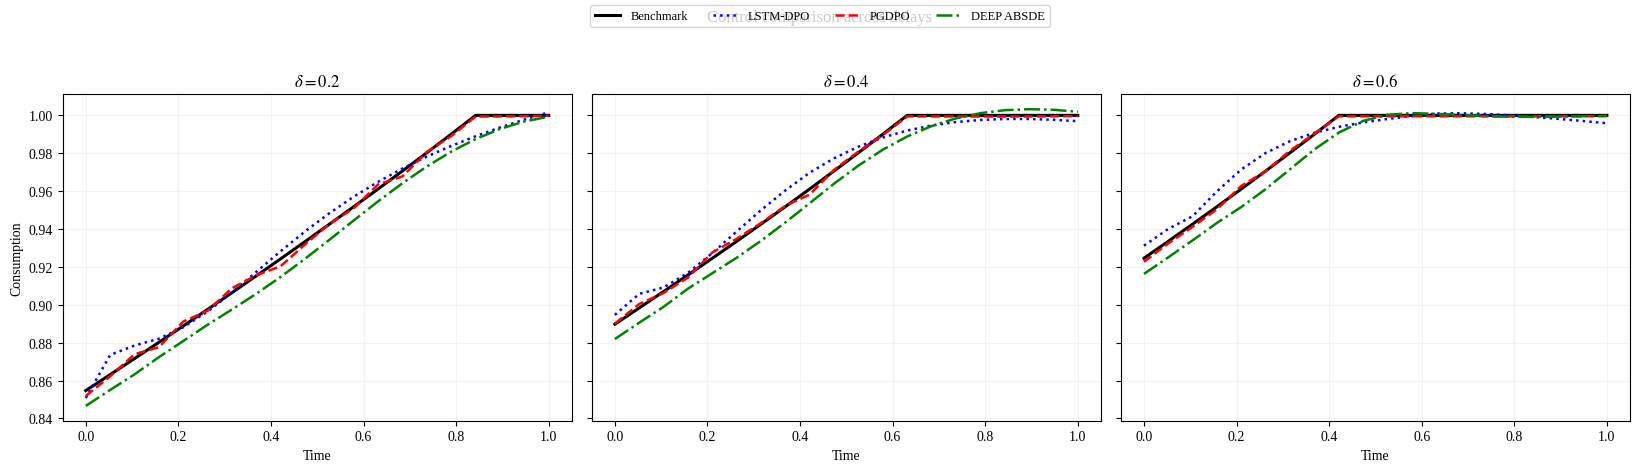

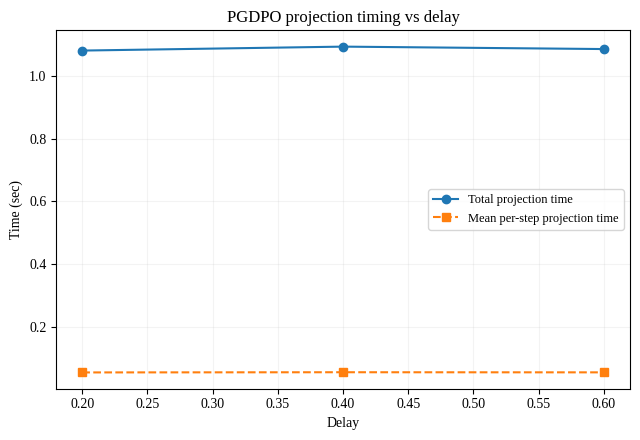

In [ ]:
import copy
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})

# =============================================================================
# 0. Unified Configuration
# =============================================================================
CFG = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float64,

    # problem params
    "alpha": 0.1,
    "beta": 0.2,
    "gamma": 0.5,
    "k_terminal": 1.0,
    "T": 1.0,
    "N": 20,
    "delta": 0.4,
    "delta_list": [0.2, 0.4, 0.6],
    "X0": 1.0,

    # training params (shared)
    "train_paths": 256,
    "hidden": 64,
    "lr": 3e-4,

    # iterations
    "n_iters": 2000,
    "fabsde_iters": 5000,

    # PGDPO projection inner MC
    "proj_inner_mc": 8192,
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


def set_seed(seed: int) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)


# =============================================================================
# 1. Physics (Dynamics / Utility)
# =============================================================================
class Physics:
    """Shared physics dynamics and utilities."""

    def __init__(self, cfg: dict):
        self.alpha = cfg["alpha"]
        self.beta = cfg["beta"]
        self.gamma = cfg["gamma"]
        self.k_term = cfg["k_terminal"]

        self.h = cfg["T"] / cfg["N"]
        raw_delay_steps = cfg["delta"] / self.h
        rounded_delay_steps = int(round(raw_delay_steps))

        if not np.isclose(raw_delay_steps, rounded_delay_steps, atol=1e-10):
            raise ValueError(
                f"delta={cfg['delta']} is not aligned with h={self.h}. "
                f"Need delta/h to be (approximately) an integer."
            )

        self.delay_steps = rounded_delay_steps

    def step(self, x_now, x_lag, u, dW):
        drift = self.alpha * x_lag - u
        diff = self.beta * x_lag
        return x_now + drift * self.h + diff * dW

    def utility(self, u):
        return (u ** self.gamma) / self.gamma

    def get_terminal_reward(self, x_final):
        return self.k_term * x_final

    def init_history(self, batch_size: int, x0: float):
        return [
            torch.full((batch_size,), x0, device=DEVICE)
            for _ in range(self.delay_steps + 1)
        ]


# =============================================================================
# 2. Models
# =============================================================================
class BaseLSTM(nn.Module):
    def __init__(self, output_dim: int, hidden_dim: int):
        super().__init__()
        self.lstm = nn.LSTM(3, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, t, x, x_lag, hidden):
        inp = torch.stack([t, x, x_lag], dim=1).unsqueeze(1)  # (B,1,3)
        out, new_hidden = self.lstm(inp, hidden)
        return self.fc(out[:, -1, :]), new_hidden


class PolicyNet(BaseLSTM):
    def __init__(self, hidden_dim):
        super().__init__(output_dim=1, hidden_dim=hidden_dim)

    def forward(self, t, x, x_lag, hidden):
        raw, h_new = super().forward(t, x, x_lag, hidden)
        return torch.nn.functional.softplus(raw).squeeze(-1), h_new


class FABSDE_Net(BaseLSTM):
    def __init__(self, hidden_dim):
        super().__init__(output_dim=4, hidden_dim=hidden_dim)  # Y, Z, EY, EZ

    def forward(self, t, x, x_lag, hidden):
        raw, new_hidden = super().forward(t, x, x_lag, hidden)
        Y = torch.nn.functional.softplus(raw[:, 0]) + 1e-6
        Z = raw[:, 1]
        EY = torch.nn.functional.softplus(raw[:, 2]) + 1e-6
        EZ = raw[:, 3]
        return Y, Z, EY, EZ, new_hidden


# =============================================================================
# 3. Benchmark Solvers
# =============================================================================
def solve_analytic(cfg):
    phy = Physics(cfg)
    p = np.zeros(cfg["N"] + 1)
    p[cfg["N"] - phy.delay_steps:] = cfg["k_terminal"]

    for i in range(cfg["N"] - phy.delay_steps - 1, -1, -1):
        p[i] = p[i + 1] + cfg["alpha"] * phy.h * p[i + 1 + phy.delay_steps]

    c_star = np.maximum(p, 1e-12) ** (1.0 / (cfg["gamma"] - 1.0))
    return c_star, p


def train_pg(policy: nn.Module, phy: Physics, cfg: dict):
    print(f">>> Training PG (Algo 1)... delta={cfg['delta']}")
    opt = optim.Adam(policy.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["n_iters"] + 1):
        opt.zero_grad()

        dW = torch.randn(cfg["train_paths"], cfg["N"], device=DEVICE) * np.sqrt(phy.h)
        X = torch.zeros(cfg["train_paths"], cfg["N"] + phy.delay_steps + 1, device=DEVICE)
        X[:, : phy.delay_steps + 1] = cfg["X0"]

        run_util = 0.0
        hidden = None

        for n in range(cfg["N"]):
            k = phy.delay_steps + n
            t_val = torch.full((cfg["train_paths"],), n * phy.h, device=DEVICE)
            c_n, hidden = policy(t_val, X[:, k], X[:, n], hidden)
            X[:, k + 1] = phy.step(X[:, k], X[:, n], c_n, dW[:, n])
            run_util += phy.utility(c_n) * phy.h

        loss = -(run_util + phy.get_terminal_reward(X[:, -1])).mean()
        if it % 200 == 0:
            print(f"{it}th epoch LSTM-DPO loss: {loss.item():.6f}")
        loss.backward()
        opt.step()

    return policy


def compute_ppgdpo(base_policy: nn.Module, phy: Physics, cfg: dict):
    print(f">>> Computing PGDPO (Algo 2)... delta={cfg['delta']}")
    c_proj, p_proj = [], []
    per_step_times = []

    real_hist = [torch.tensor([cfg["X0"]], device=DEVICE) for _ in range(phy.delay_steps + 1)]

    total_proj_t0 = time.time()

    for i in range(cfg["N"]):
        step_t0 = time.time()

        x_start = real_hist[-1].detach().clone().requires_grad_(True)
        n_inner = cfg["proj_inner_mc"]

        past_hist = torch.stack(real_hist[:-1]).detach().expand(-1, n_inner)
        curr_state = x_start.expand(n_inner)
        inner_X = [past_hist[k] for k in range(phy.delay_steps)] + [curr_state]

        hidden_inner = None
        J_future = 0.0

        for step in range(cfg["N"] - i):
            abs_step = i + step
            k_idx = phy.delay_steps + step
            t_val = torch.full((n_inner,), abs_step * phy.h, device=DEVICE)

            x_now, x_lag = inner_X[k_idx], inner_X[step]
            c_val, hidden_inner = base_policy(t_val, x_now, x_lag, hidden_inner)

            dW = torch.randn(n_inner, device=DEVICE) * np.sqrt(phy.h)
            x_next = phy.step(x_now, x_lag, c_val, dW)
            inner_X.append(x_next)
            J_future += phy.utility(c_val) * phy.h

        J_total = J_future + phy.get_terminal_reward(inner_X[-1])
        grads = torch.autograd.grad(J_total.sum(), x_start)
        p_t = grads[0].item() / n_inner

        p_clamped = max(p_t, 1e-12)
        c_star = p_clamped ** (1.0 / (cfg["gamma"] - 1.0))

        c_proj.append(c_star)
        p_proj.append(p_t)

        x_next_real = phy.step(
            real_hist[-1],
            real_hist[-(phy.delay_steps + 1)],
            torch.tensor([c_star], device=DEVICE),
            0.0,
        )
        real_hist.append(x_next_real)

        step_elapsed = time.time() - step_t0
        per_step_times.append(step_elapsed)

    total_proj_elapsed = time.time() - total_proj_t0

    timing_info = {
        "projection_total_sec": total_proj_elapsed,
        "projection_mean_per_step_sec": float(np.mean(per_step_times)),
        "projection_std_per_step_sec": float(np.std(per_step_times)),
        "projection_per_step_sec": np.array(per_step_times),
    }

    return np.array(c_proj), np.array(p_proj), timing_info


def train_fabsde(phy: Physics, cfg: dict):
    print(f">>> Training FABSDE (Algo 3)... delta={cfg['delta']}")
    net = FABSDE_Net(hidden_dim=cfg["hidden"]).to(DEVICE)
    opt = optim.Adam(net.parameters(), lr=cfg["lr"])

    for it in range(1, cfg["fabsde_iters"] + 1):
        opt.zero_grad()

        B = cfg["train_paths"]
        dW = torch.randn(B, cfg["N"], device=DEVICE) * np.sqrt(phy.h)
        X = phy.init_history(B, cfg["X0"])

        preds = {"Y": [], "Z": [], "EY": [], "EZ": []}
        tildeY = [None] * (cfg["N"] + 1)
        hidden = None

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_i = torch.full((B,), i * phy.h, device=DEVICE)

            Y, Z, EY, EZ, hidden = net(t_i, X[k], X[i], hidden)
            preds["Y"].append(Y)
            preds["Z"].append(Z)
            preds["EY"].append(EY)
            preds["EZ"].append(EZ)

            c_i = Y.pow(1.0 / (cfg["gamma"] - 1.0))
            X.append(phy.step(X[k], X[i], c_i, dW[:, i]))

            f_i = (cfg["alpha"] * EY + cfg["beta"] * EZ) if i <= cfg["N"] - phy.delay_steps else torch.zeros_like(Y)
            tildeY[i + 1] = Y - f_i * phy.h + Z * dW[:, i]

        t_N = torch.full((B,), cfg["N"] * phy.h, device=DEVICE)
        Y_N, Z_N, EY_N, EZ_N, _ = net(t_N, X[-1], X[cfg["N"]], hidden)
        preds["Y"].append(Y_N)
        preds["Z"].append(Z_N)
        preds["EY"].append(EY_N)
        preds["EZ"].append(EZ_N)

        L1 = sum((preds["Y"][i + 1] - tildeY[i + 1]).pow(2).mean() for i in range(cfg["N"]))
        L1 += (preds["Y"][cfg["N"]] - cfg["k_terminal"]).pow(2).mean()

        L2 = 0.0
        if phy.delay_steps <= cfg["N"]:
            limit = cfg["N"] - phy.delay_steps
            L2 += sum((preds["EY"][i] - tildeY[i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))
            L2 += sum((preds["EZ"][i] - preds["Z"][i + phy.delay_steps]).pow(2).mean() for i in range(limit + 1))

        loss = L1 + L2
        loss.backward()

        if it % 500 == 0:
            print(f"{it}th epoch Deep ABSDE loss: {loss.item():.6f}")
        opt.step()

    with torch.no_grad():
        c_path, Y_path = [], []
        hidden = None
        X = phy.init_history(1, cfg["X0"])

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            res = net(torch.tensor([i * phy.h], device=DEVICE), X[k], X[i], hidden)
            hidden = res[-1]
            c_val = res[0].pow(1.0 / (cfg["gamma"] - 1.0))
            c_path.append(c_val.item())
            Y_path.append(res[0].item())
            X.append(phy.step(X[k], X[i], c_val, 0.0))

    return np.array(c_path), np.array(Y_path)


# =============================================================================
# 4. Evaluation / Plotting
# =============================================================================
def eval_pg_policy(policy: nn.Module, phy: Physics, cfg: dict):
    c_pg = []

    with torch.no_grad():
        hidden = None
        X = phy.init_history(1, cfg["X0"])

        for i in range(cfg["N"]):
            k = phy.delay_steps + i
            t_i = torch.tensor([i * phy.h], device=DEVICE)

            x_now = X[k]
            x_lag = X[i]

            # Policy receives only current state x_now.
            c_i, hidden = policy(t_i, x_now, hidden)
            c_pg.append(float(c_i.item()))

            # Dynamics still uses x_lag.
            x_next = phy.step(x_now, x_lag, c_i, 0.0)
            X.append(x_next)

    return np.array(c_pg)


def compute_metrics(gt: np.ndarray, pred: np.ndarray):
    min_l = min(len(gt), len(pred))
    rmse = np.sqrt(np.mean((pred[:min_l] - gt[:min_l]) ** 2))
    mae = np.mean(np.abs(pred[:min_l] - gt[:min_l]))
    return rmse, mae


def print_metrics_table(results_all):
    print("\n" + "=" * 120)
    print(f"{'delay':<10} | {'algo':<12} | {'RMSE':<12} | {'MAE':<12} | {'proj_total_sec':<16} | {'proj_mean_step_sec':<18}")
    print("-" * 120)
    for delta, out in results_all.items():
        gt = out["benchmark"]
        proj_total = out["timing"]["projection_total_sec"]
        proj_mean = out["timing"]["projection_mean_per_step_sec"]

        for name in ["PG", "PGDPO", "FABSDE"]:
            rmse, mae = compute_metrics(gt, out[name])

            if name == "PGDPO":
                print(f"{delta:<10.2f} | {name:<12} | {rmse:<12.6f} | {mae:<12.6f} | {proj_total:<16.6f} | {proj_mean:<18.6f}")
            else:
                print(f"{delta:<10.2f} | {name:<12} | {rmse:<12.6f} | {mae:<12.6f} | {'-':<16} | {'-':<18}")
    print("=" * 120)


def plot_all_algorithms_for_each_delay(results_all):
    n_delays = len(results_all)
    fig, axes = plt.subplots(1, n_delays, figsize=(5.5 * n_delays, 4.5), sharey=True)

    if n_delays == 1:
        axes = [axes]

    for ax, (delta, out) in zip(axes, results_all.items()):
        t_grid = out["t_grid"]
        ax.plot(t_grid, out["benchmark"], "k-", lw=2.2, label="Benchmark")
        ax.plot(t_grid, out["PG"], "b:", lw=1.8, label="LSTM-DPO")
        ax.plot(t_grid, out["PGDPO"], "r--", lw=1.8, label="PGDPO")
        ax.plot(t_grid, out["FABSDE"], "g-.", lw=1.8, label="DEEP ABSDE")
        ax.set_title(rf"$\delta={delta}$")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.15)

    axes[0].set_ylabel("Consumption")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    fig.suptitle("Control comparison across delays", y=1.04)
    plt.tight_layout()
    plt.show()


def plot_projection_times(results_all):
    delays = list(results_all.keys())
    total_times = [results_all[d]["timing"]["projection_total_sec"] for d in delays]
    mean_step_times = [results_all[d]["timing"]["projection_mean_per_step_sec"] for d in delays]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(delays, total_times, "o-", label="Total projection time")
    plt.plot(delays, mean_step_times, "s--", label="Mean per-step projection time")
    plt.xlabel("Delay")
    plt.ylabel("Time (sec)")
    plt.title("PGDPO projection timing vs delay")
    plt.grid(alpha=0.15)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_single_delay_experiment(cfg_local):
    set_seed(cfg_local["seed"])
    phy = Physics(cfg_local)

    # 1) Analytic Benchmark
    c_ana, _ = solve_analytic(cfg_local)

    # 2) LSTM-DPO (Algo 1)
    policy_pg = train_pg(PolicyNet(hidden_dim=cfg_local["hidden"]).to(DEVICE), phy, cfg_local)
    c_pg = eval_pg_policy(policy_pg, phy, cfg_local)

    # 3) PGDPO (Algo 2)
    c_proj, _, timing_info = compute_ppgdpo(policy_pg, phy, cfg_local)

    # 4) DEEP ABSDE (Algo 3)
    c_fabsde, _ = train_fabsde(phy, cfg_local)

    gt = c_ana[:-1]
    t_grid = np.linspace(0, cfg_local["T"], cfg_local["N"])

    return {
        "benchmark": gt,
        "PG": c_pg,
        "PGDPO": c_proj,
        "FABSDE": c_fabsde,
        "timing": timing_info,
        "t_grid": t_grid,
    }


def evaluate_models_delay_sweep():
    results_all = {}

    for delta in CFG["delta_list"]:
        print("\n" + "#" * 100)
        print(f"Running experiment for delay delta = {delta}")
        print("#" * 100)

        cfg_local = copy.deepcopy(CFG)
        cfg_local["delta"] = delta

        out = run_single_delay_experiment(cfg_local)
        results_all[delta] = out

        print(
            f"[delta={delta}] projection total = {out['timing']['projection_total_sec']:.6f} sec, "
            f"mean per-step = {out['timing']['projection_mean_per_step_sec']:.6f} sec"
        )

    print_metrics_table(results_all)
    plot_all_algorithms_for_each_delay(results_all)
    plot_projection_times(results_all)

    return results_all


if __name__ == "__main__":
    results_all = evaluate_models_delay_sweep()


####################################################################################################
Running Benchmark 2 experiment for delay delta = 0.4
####################################################################################################

[Warmup / LSTM-DPO] delta=0.4
[Warmup] iter=500, J=-60.5926
[Warmup] iter=1000, J=-61.6924
[Warmup] iter=1500, J=-62.2072
[Warmup] iter=2000, J=-62.4086
[Warmup] iter=2500, J=-62.5130
[Warmup] iter=3000, J=-62.3402
[Warmup] iter=3500, J=-62.4171
[Warmup] iter=4000, J=-62.5014
[Warmup] iter=4500, J=-62.5056
[Warmup] iter=5000, J=-62.4837

[MV-FABSDE] delta=0.4
[MV-FABSDE] iter=500, L1=1.228608, L2=0.225570, total=1.454178
[MV-FABSDE] iter=1000, L1=0.306615, L2=0.088310, total=0.394925
[MV-FABSDE] iter=1500, L1=0.189318, L2=0.066909, total=0.256227
[MV-FABSDE] iter=2000, L1=0.094819, L2=0.033884, total=0.128703
[MV-FABSDE] iter=2500, L1=0.029864, L2=0.010531, total=0.040395
[MV-FABSDE] iter=3000, L1=0.007463, L2=0.002233, total=0.00969

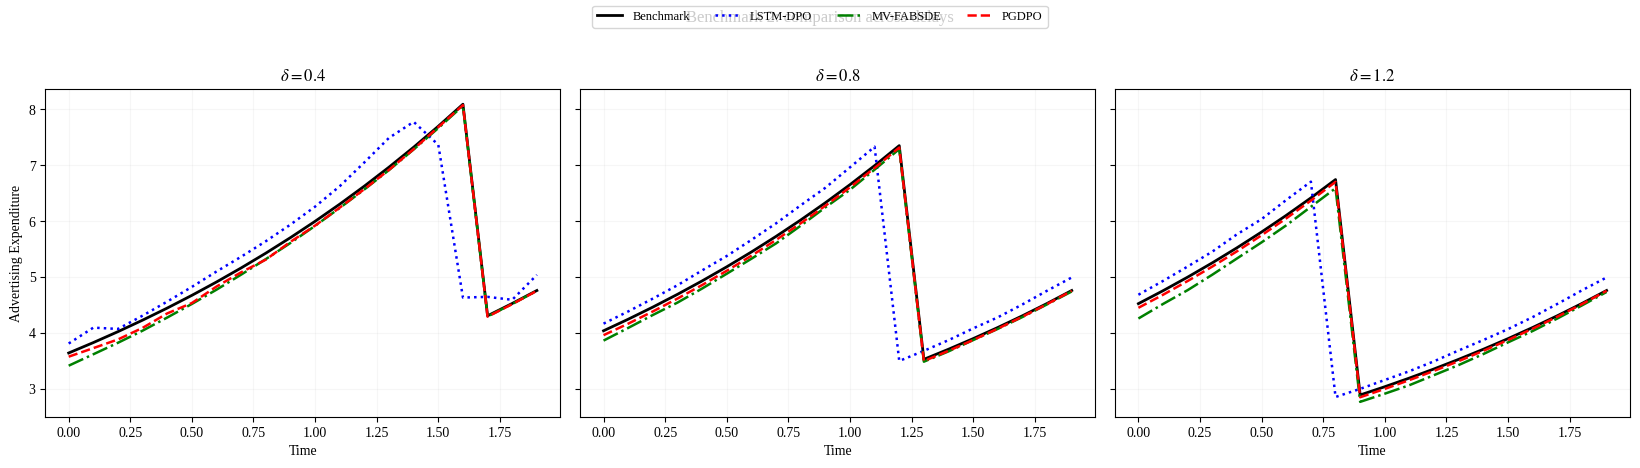

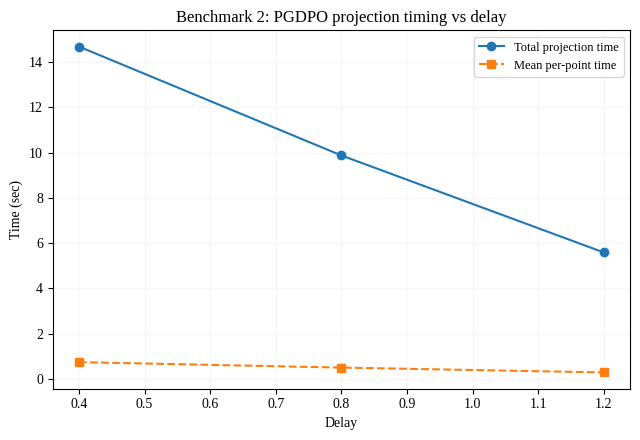

In [ ]:
import math
import random
import time
import copy
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


# ============================================================
# 0. Matplotlib / Font Settings (Type-3 font prevention)
# ============================================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})


# ============================================================
# 1. Unified Configuration
# ============================================================
CFG: Dict = {
    # reproducibility / device / dtype
    "seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float32,

    # dynamics / cost
    "a0": -0.5,
    "b0": 1.0,
    "b1": 0.8,
    "sigma": 0.2,
    "R": 1.0,
    "S0": -10.0,

    # time grid
    "T": 2.0,
    "N_steps": 20,
    "delta": 1.0,
    "delta_list": [0.4, 0.8, 1.2],   # NEW: delay sweep

    # initial condition
    "x0": 0.0,

    # Algo 1 (Warmup / LSTM-DPO)
    "batch_size": 256,
    "warmup_iters": 5000,
    "lr": 5e-4,

    # Algo 2 (MV-FABSDE)
    "fbsde_iters": 5000,
    "fbsde_lr": 5e-4,
    "fbsde_decay_step": 10000,

    # Stage2 projection (P-PGDPO projection)
    "N_mc_stage2": 8,
    "N_branch": 10,
    "N_compare": 51,
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


# ============================================================
# 2. Utilities
# ============================================================
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def dt(cfg: Dict) -> float:
    return cfg["T"] / cfg["N_steps"]


def delay_steps(cfg: Dict) -> int:
    raw = cfg["delta"] / dt(cfg)
    d = int(round(raw))
    if not np.isclose(raw, d, atol=1e-10):
        raise ValueError(
            f"delta={cfg['delta']} is not aligned with dt={dt(cfg)}. "
            f"Need delta/dt to be (approximately) an integer."
        )
    return max(1, d)


def make_time_norm(n: int, cfg: Dict, batch: int, device: torch.device) -> torch.Tensor:
    t = n * dt(cfg)
    return torch.full((batch,), t / cfg["T"], device=device)


def drift_x(x: torch.Tensor, v: torch.Tensor, v_delayed: torch.Tensor, cfg: Dict) -> torch.Tensor:
    return cfg["a0"] * x + cfg["b0"] * v + cfg["b1"] * v_delayed


def get_v_delayed(v_hist: torch.Tensor, n: int, D: int, device: torch.device) -> torch.Tensor:
    if n - D >= 0:
        return v_hist[:, n - D]
    return torch.zeros(v_hist.size(0), device=device, dtype=v_hist.dtype)


# ============================================================
# 3. Models
# ============================================================
class LSTMPolicy(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head = nn.Linear(hidden_size, 1)
        with torch.no_grad():
            self.head.bias.fill_(0.5)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self, t_norm: torch.Tensor, x_t: torch.Tensor, h: torch.Tensor, c: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        v_raw = self.head(h_next).squeeze(-1)
        v = torch.nn.functional.softplus(v_raw)
        return v, h_next, c_next


class FBSDENet(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head_Y = nn.Linear(hidden_size, 1)
        self.head_Z = nn.Linear(hidden_size, 1)
        self.head_EY = nn.Linear(hidden_size, 1)
        with torch.no_grad():
            self.head_Y.bias.fill_(-5.0)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self, t_norm: torch.Tensor, x_t: torch.Tensor, h: torch.Tensor, c: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        y = self.head_Y(h_next).squeeze(-1)
        z = self.head_Z(h_next).squeeze(-1)
        ey = self.head_EY(h_next).squeeze(-1)
        return y, z, ey, h_next, c_next


# ============================================================
# 4. Algorithm 1: Warmup (LSTM-DPO)
# ============================================================
def simulate_batch_episode_pg(policy: LSTMPolicy, cfg: Dict, detach_policy: bool = False) -> torch.Tensor:
    device = DEVICE
    N, D = cfg["N_steps"], delay_steps(cfg)
    batch = cfg["batch_size"]

    x = torch.full((batch,), cfg["x0"], device=device)
    v_hist = torch.zeros(batch, N + 1, device=device)

    h, c = policy.init_hidden(batch, device)
    cost = torch.zeros(batch, device=device)

    for n in range(N):
        t_norm = make_time_norm(n, cfg, batch, device)
        if detach_policy:
            with torch.no_grad():
                v, h, c = policy.forward_step(t_norm, x, h, c)
        else:
            v, h, c = policy.forward_step(t_norm, x, h, c)

        v_hist[:, n] = v
        v_del = get_v_delayed(v_hist, n, D, device)

        dB = math.sqrt(dt(cfg)) * torch.randn(batch, device=device)
        x = x + drift_x(x, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB
        cost = cost + cfg["R"] * v**2 * dt(cfg)

    cost = cost + cfg["S0"] * x
    return cost.mean()


def warmup_train(policy: LSTMPolicy, cfg: Dict) -> LSTMPolicy:
    print(f"\n[Warmup / LSTM-DPO] delta={cfg['delta']}")
    policy.to(DEVICE)
    policy.train()
    opt = optim.Adam(policy.parameters(), lr=cfg["lr"])

    for it in range(cfg["warmup_iters"]):
        opt.zero_grad(set_to_none=True)
        J = simulate_batch_episode_pg(policy, cfg, detach_policy=False)
        J.backward()
        opt.step()
        if (it + 1) % 500 == 0:
            print(f"[Warmup] iter={it+1}, J={J.item():.4f}")

    return policy


def rollout_policy_pg_deterministic(policy: LSTMPolicy, cfg: Dict) -> Dict[str, List[torch.Tensor]]:
    device = DEVICE
    T, N, D = cfg["T"], cfg["N_steps"], delay_steps(cfg)
    policy.eval()

    x = torch.full((1,), cfg["x0"], device=device)
    v_hist = torch.zeros(1, N + 1, device=device)
    h, c = policy.init_hidden(1, device)

    xs, vs, hs, cs, v_hists = [], [], [], [], []
    with torch.no_grad():
        for n in range(N):
            xs.append(x.clone())
            hs.append(h.clone())
            cs.append(c.clone())
            v_hists.append(v_hist.clone())

            t_norm = torch.full((1,), (n * dt(cfg)) / T, device=device)
            v, h, c = policy.forward_step(t_norm, x, h, c)
            vs.append(v.clone())

            v_hist[:, n] = v
            v_del = get_v_delayed(v_hist, n, D, device)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg)

        xs.append(x.clone())

    return {"xs": xs, "vs": vs, "hs": hs, "cs": cs, "v_hists": v_hists}


# ============================================================
# 5. Algorithm 2: MV-FABSDE
# ============================================================
def train_fbsde(net: FBSDENet, cfg: Dict) -> FBSDENet:
    print(f"\n[MV-FABSDE] delta={cfg['delta']}")
    net.to(DEVICE)
    net.train()

    opt = optim.Adam(net.parameters(), lr=cfg["fbsde_lr"])
    scheduler = optim.lr_scheduler.StepLR(opt, step_size=cfg["fbsde_decay_step"], gamma=0.1)
    mse = nn.MSELoss()

    N, D = cfg["N_steps"], delay_steps(cfg)
    batch = cfg["batch_size"]
    T = cfg["T"]

    for it in range(cfg["fbsde_iters"]):
        dB = torch.randn(batch, N, device=DEVICE) * math.sqrt(dt(cfg))

        x = torch.full((batch,), cfg["x0"], device=DEVICE)
        v_hist = torch.zeros(batch, N + 1, device=DEVICE)
        h, c = net.init_hidden(batch, DEVICE)

        Y_pred = [None] * (N + 1)
        Z_pred = [None] * (N + 1)
        EY_pred = [None] * (N + 1)
        tildeY = [None] * (N + 1)

        t0 = torch.zeros(batch, device=DEVICE)
        y, z, ey, h, c = net.forward_step(t0, x, h, c)
        Y_pred[0], Z_pred[0], EY_pred[0] = y, z, ey

        for i in range(N):
            y_i, z_i, ey_i = Y_pred[i], Z_pred[i], EY_pred[i]
            ey_used = ey_i if i <= N - D else torch.zeros_like(ey_i)

            v_val = - (cfg["b0"] * y_i + cfg["b1"] * ey_used) / (2.0 * cfg["R"])
            v = torch.relu(v_val)
            v_hist[:, i] = v

            v_del = get_v_delayed(v_hist, i, D, DEVICE)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB[:, i]

            tildeY[i + 1] = y_i - cfg["a0"] * y_i * dt(cfg) + z_i * dB[:, i]

            t_next = torch.full((batch,), ((i + 1) * dt(cfg)) / T, device=DEVICE)
            y, z, ey, h, c = net.forward_step(t_next, x, h, c)
            Y_pred[i + 1], Z_pred[i + 1], EY_pred[i + 1] = y, z, ey

        L1 = 0.0
        for i in range(N):
            L1 = L1 + mse(Y_pred[i + 1], tildeY[i + 1])
        L1 = L1 + mse(Y_pred[N], torch.full((batch,), cfg["S0"], device=DEVICE))

        L2 = 0.0
        for i in range(0, N - D + 1):
            L2 = L2 + mse(EY_pred[i], tildeY[i + D])

        L1 = L1 / max(1, N)
        L2 = L2 / max(1, N - D + 1)
        loss = L1 + L2

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()
        scheduler.step()

        if (it + 1) % 500 == 0:
            print(f"[MV-FABSDE] iter={it+1}, L1={L1.item():.6f}, L2={L2.item():.6f}, total={loss.item():.6f}")

    return net


def rollout_fbsde_deterministic(net: FBSDENet, cfg: Dict) -> List[torch.Tensor]:
    net.eval()

    N, D = cfg["N_steps"], delay_steps(cfg)
    T = cfg["T"]

    x = torch.full((1,), cfg["x0"], device=DEVICE)
    v_hist = torch.zeros(1, N + 1, device=DEVICE)
    h, c = net.init_hidden(1, DEVICE)

    vs = []
    with torch.no_grad():
        for i in range(N):
            t_norm = torch.full((1,), (i * dt(cfg)) / T, device=DEVICE)
            y, z, ey, h, c = net.forward_step(t_norm, x, h, c)
            ey_used = ey if i <= N - D else torch.zeros_like(ey)
            v_val = - (cfg["b0"] * y + cfg["b1"] * ey_used) / (2.0 * cfg["R"])
            v = torch.relu(v_val)

            vs.append(v.clone())
            v_hist[:, i] = v
            v_del = get_v_delayed(v_hist, i, D, DEVICE)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg)

    return vs


# ============================================================
# 6. Benchmark
# ============================================================
def analytic_solution(cfg: Dict) -> Tuple[np.ndarray, np.ndarray]:
    T, N = cfg["T"], cfg["N_steps"]
    a0, b0, b1 = cfg["a0"], cfg["b0"], cfg["b1"]
    R, S0 = cfg["R"], cfg["S0"]
    D = delay_steps(cfg)

    t_grid = np.linspace(0, T, N + 1)
    y = S0 * np.exp(a0 * (T - t_grid))

    u = np.zeros_like(y)
    for i in range(N + 1):
        term1 = b0 * y[i]
        term2 = b1 * y[i + D] if (i + D) <= N else 0.0
        u[i] = max(0.0, - (term1 + term2) / (2.0 * R))

    return t_grid, u


def mae_rmse(y_hat: np.ndarray, y_ref: np.ndarray) -> Tuple[float, float]:
    y_hat = np.asarray(y_hat).reshape(-1)
    y_ref = np.asarray(y_ref).reshape(-1)
    err = y_hat - y_ref
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    return mae, rmse


# ============================================================
# 7. P-PGDPO Projection
# ============================================================
def estimate_costate_mc(
    policy: LSTMPolicy,
    cfg: Dict,
    n0: int,
    x0_val: torch.Tensor,
    h0: torch.Tensor,
    c0: torch.Tensor,
    v_hist0: torch.Tensor,
    M: int,
) -> torch.Tensor:
    policy.eval()

    N, D = cfg["N_steps"], delay_steps(cfg)
    T = cfg["T"]

    lambdas = []
    for _ in range(M):
        x_init = x0_val.clone().detach().requires_grad_(True)
        x = x_init

        h = h0.clone().detach()
        c = c0.clone().detach()
        v_hist = v_hist0.clone().detach()

        cost = torch.zeros(1, device=DEVICE)
        for n in range(n0, N):
            t_norm = torch.full((1,), (n * dt(cfg)) / T, device=DEVICE)
            v, h, c = policy.forward_step(t_norm, x, h, c)

            v_hist[:, n] = v
            v_del = get_v_delayed(v_hist, n, D, DEVICE)

            dB = math.sqrt(dt(cfg)) * torch.randn(1, device=DEVICE)
            x = x + drift_x(x, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB
            cost = cost + cfg["R"] * v**2 * dt(cfg)

        cost = cost + cfg["S0"] * x
        (grad_x,) = torch.autograd.grad(cost, x_init, retain_graph=False, create_graph=False)
        lambdas.append(grad_x.detach())

    return torch.mean(torch.stack(lambdas, dim=0), dim=0)


def project_p_pgdpo(
    policy_pg: LSTMPolicy,
    cfg: Dict,
    t_grid: np.ndarray,
    rollout_pg: Dict[str, List[torch.Tensor]],
) -> Tuple[np.ndarray, np.ndarray, Dict[str, float]]:
    N = cfg["N_steps"]
    D = delay_steps(cfg)

    idx_list = sorted(
        set(
            int(round(i * (N - 1) / (cfg["N_compare"] - 1)))
            for i in range(cfg["N_compare"])
        )
    )

    xs = rollout_pg["xs"]
    hs = rollout_pg["hs"]
    cs = rollout_pg["cs"]
    v_hists = rollout_pg["v_hists"]

    v_pmp_list = []
    t_cmp = []
    per_point_times = []

    total_t0 = time.time()

    for n in idx_list:
        point_t0 = time.time()

        lam_t = estimate_costate_mc(
            policy_pg, cfg, n, xs[n], hs[n], cs[n], v_hists[n], M=cfg["N_mc_stage2"]
        ).item()

        if n + D >= N:
            lam_t_delta = cfg["S0"] if (n + D) == N else 0.0
        else:
            future = []
            for _ in range(cfg["N_branch"]):
                x_curr = xs[n].clone()
                h_curr = hs[n].clone()
                c_curr = cs[n].clone()
                v_hist_curr = v_hists[n].clone()

                for k in range(n, n + D):
                    t_k_norm = torch.full((1,), (k * dt(cfg)) / cfg["T"], device=DEVICE)
                    with torch.no_grad():
                        v, h_curr, c_curr = policy_pg.forward_step(t_k_norm, x_curr, h_curr, c_curr)

                    v_hist_curr[:, k] = v
                    v_del = get_v_delayed(v_hist_curr, k, D, DEVICE)
                    dB = math.sqrt(dt(cfg)) * torch.randn(1, device=DEVICE)
                    x_curr = x_curr + drift_x(x_curr, v, v_del, cfg) * dt(cfg) + cfg["sigma"] * dB

                lam_future = estimate_costate_mc(
                    policy_pg, cfg, n + D, x_curr, h_curr, c_curr, v_hist_curr, M=cfg["N_mc_stage2"]
                ).item()
                future.append(lam_future)

            lam_t_delta = float(np.mean(future))

        val = - (cfg["b0"] * lam_t + cfg["b1"] * lam_t_delta) / (2.0 * cfg["R"])
        v_pmp_list.append(max(0.0, val))
        t_cmp.append(t_grid[n])

        per_point_times.append(time.time() - point_t0)

    total_elapsed = time.time() - total_t0
    timing_info = {
        "projection_total_sec": float(total_elapsed),
        "projection_mean_per_point_sec": float(np.mean(per_point_times)) if len(per_point_times) > 0 else 0.0,
        "projection_std_per_point_sec": float(np.std(per_point_times)) if len(per_point_times) > 0 else 0.0,
        "n_projection_points": int(len(per_point_times)),
    }

    return np.array(t_cmp), np.array(v_pmp_list), timing_info


# ============================================================
# 8. Plotting / Reporting
# ============================================================
def plot_controls_all_delays(results_all: Dict[float, Dict]) -> None:
    n_delays = len(results_all)
    fig, axes = plt.subplots(1, n_delays, figsize=(5.5 * n_delays, 4.5), sharey=True)

    if n_delays == 1:
        axes = [axes]

    for ax, (delta, out) in zip(axes, results_all.items()):
        ax.plot(out["t_plot"], out["benchmark"], "k-", lw=2, label="Benchmark")
        ax.plot(out["t_plot"], out["LSTM-DPO"], "b:", lw=1.8, label="LSTM-DPO")
        ax.plot(out["t_plot"], out["MV-FABSDE"], "g-.", lw=1.8, label="MV-FABSDE")
        ax.plot(out["t_plot"], out["PGDPO"], "r--", lw=1.8, label="PGDPO")
        ax.set_title(rf"$\delta={delta}$")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.1)

    axes[0].set_ylabel("Advertising Expenditure")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    fig.suptitle("Benchmark 2: comparison across delays", y=1.03)
    plt.tight_layout()
    plt.show()


def plot_projection_times(results_all: Dict[float, Dict]) -> None:
    delays = list(results_all.keys())
    total_times = [results_all[d]["timing"]["projection_total_sec"] for d in delays]
    mean_point_times = [results_all[d]["timing"]["projection_mean_per_point_sec"] for d in delays]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(delays, total_times, "o-", label="Total projection time")
    plt.plot(delays, mean_point_times, "s--", label="Mean per-point time")
    plt.xlabel("Delay")
    plt.ylabel("Time (sec)")
    plt.title("Benchmark 2: PGDPO projection timing vs delay")
    plt.grid(alpha=0.1)
    plt.legend()
    plt.tight_layout()
    plt.show()


def print_metrics_table(results_all: Dict[float, Dict]) -> None:
    print("\n" + "=" * 120)
    print(f"{'delay':<10} | {'algo':<15} | {'RMSE':<12} | {'MAE':<12} | {'proj_total_sec':<16} | {'proj_mean_point_sec':<20}")
    print("-" * 120)

    for delta, out in results_all.items():
        for name in ["LSTM-DPO", "MV-FABSDE", "PGDPO"]:
            rmse = out["metrics"][name]["RMSE"]
            mae = out["metrics"][name]["MAE"]

            if name == "PGDPO":
                print(
                    f"{delta:<10.3f} | {name:<15} | {rmse:<12.6f} | {mae:<12.6f} | "
                    f"{out['timing']['projection_total_sec']:<16.6f} | "
                    f"{out['timing']['projection_mean_per_point_sec']:<20.6f}"
                )
            else:
                print(
                    f"{delta:<10.3f} | {name:<15} | {rmse:<12.6f} | {mae:<12.6f} | "
                    f"{'-':<16} | {'-':<20}"
                )

    print("=" * 120)


# ============================================================
# 9. Single-delay runner
# ============================================================
def run_one_delay(cfg: Dict) -> Dict:
    set_seed(cfg["seed"])

    # --- Algo 1 ---
    policy_pg = LSTMPolicy(hidden_size=64)
    policy_pg = warmup_train(policy_pg, cfg)

    # --- Algo 2 ---
    fbsde_net = FBSDENet(hidden_size=64)
    fbsde_net = train_fbsde(fbsde_net, cfg)

    # --- Benchmark ---
    t_grid_full, v_star_full = analytic_solution(cfg)
    t_plot = t_grid_full[:-1]
    v_star = v_star_full[:-1]

    # --- Algo 1 rollout ---
    rollout_pg = rollout_policy_pg_deterministic(policy_pg, cfg)
    v_pg = np.array([v.item() for v in rollout_pg["vs"]])

    # --- Algo 2 rollout ---
    v_fbsde_list = rollout_fbsde_deterministic(fbsde_net, cfg)
    v_fbsde = np.array([v.item() for v in v_fbsde_list])

    # --- PGDPO projection ---
    t_cmp, v_pmp, timing_info = project_p_pgdpo(policy_pg, cfg, t_grid_full, rollout_pg)

    # compare on projection grid
    v_star_cmp = np.interp(t_cmp, t_grid_full, v_star_full)
    v_pg_cmp = np.interp(t_cmp, t_grid_full[:-1], v_pg)
    v_fbsde_cmp = np.interp(t_cmp, t_grid_full[:-1], v_fbsde)

    mae_pg, rmse_pg = mae_rmse(v_pg_cmp, v_star_cmp)
    mae_f, rmse_f = mae_rmse(v_fbsde_cmp, v_star_cmp)
    mae_pmp, rmse_pmp = mae_rmse(v_pmp, v_star_cmp)

    # for plotting on uniform N-grid
    v_pmp_on_N = np.interp(t_plot, t_cmp, v_pmp)

    print(
        f"[delta={cfg['delta']}] "
        f"LSTM-DPO RMSE/MAE = {rmse_pg:.6f}/{mae_pg:.6f}, "
        f"MV-FABSDE RMSE/MAE = {rmse_f:.6f}/{mae_f:.6f}, "
        f"PGDPO RMSE/MAE = {rmse_pmp:.6f}/{mae_pmp:.6f}"
    )
    print(
        f"[delta={cfg['delta']}] "
        f"projection total = {timing_info['projection_total_sec']:.6f} sec, "
        f"mean per-point = {timing_info['projection_mean_per_point_sec']:.6f} sec"
    )

    return {
        "t_plot": t_plot,
        "benchmark": v_star,
        "LSTM-DPO": v_pg,
        "MV-FABSDE": v_fbsde,
        "PGDPO": v_pmp_on_N,
        "timing": timing_info,
        "metrics": {
            "LSTM-DPO": {"RMSE": rmse_pg, "MAE": mae_pg},
            "MV-FABSDE": {"RMSE": rmse_f, "MAE": mae_f},
            "PGDPO": {"RMSE": rmse_pmp, "MAE": mae_pmp},
        },
    }


# ============================================================
# 10. Delay sweep
# ============================================================
def run_delay_sweep(cfg: Dict) -> Dict[float, Dict]:
    results_all = {}

    for delta in cfg["delta_list"]:
        print("\n" + "#" * 100)
        print(f"Running Benchmark 2 experiment for delay delta = {delta}")
        print("#" * 100)

        cfg_local = copy.deepcopy(cfg)
        cfg_local["delta"] = float(delta)

        out = run_one_delay(cfg_local)
        results_all[float(delta)] = out

    return results_all


# ============================================================
# 11. Main
# ============================================================
def main() -> None:
    results_all = run_delay_sweep(CFG)
    print_metrics_table(results_all)
    plot_controls_all_delays(results_all)
    plot_projection_times(results_all)


if __name__ == "__main__":
    main()


####################################################################################################
Running experiment for delay delta = 2.0
####################################################################################################

[Method 1] Starting PG Warm-up for LSTM-DPO... delta=2.0
  Iter 500, Cost J = -4.6665
  Iter 1000, Cost J = -5.3482
  Iter 1500, Cost J = -5.3595
  Iter 2000, Cost J = -5.4299
  Iter 2500, Cost J = -5.3918
  Iter 3000, Cost J = -5.5110
  Iter 3500, Cost J = -5.4369
  Iter 4000, Cost J = -5.4258

=== Running Final Comparison | delta=2.0 ===
  Calculating PGDPO projections...
  --> [TIME CHECK] 1-step projection time: 0.069719 sec
  --> [TIME CHECK] total projection time: 1.565126 sec
  --> [TIME CHECK] mean per-step projection time: 0.031301 sec

####################################################################################################
Running experiment for delay delta = 2.5
#############################################################

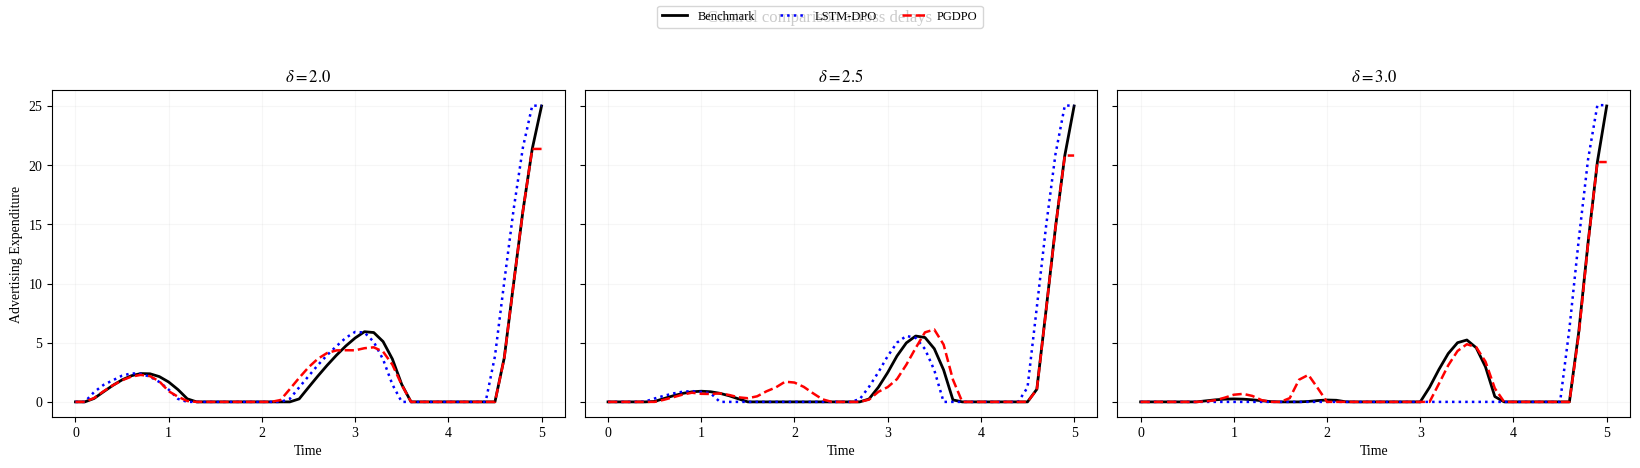

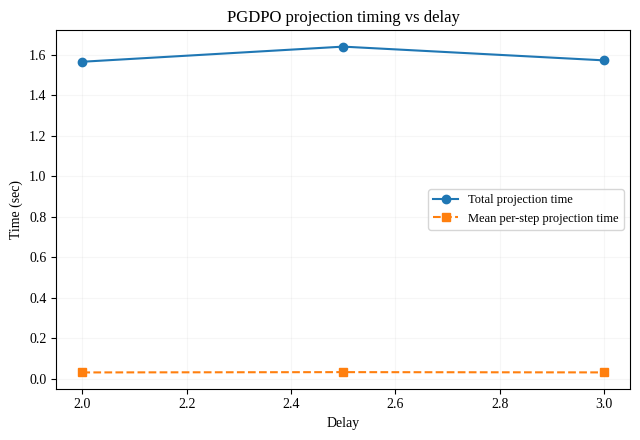

In [ ]:
import math
import time
import random
import copy
from typing import Dict, Any, Tuple, List

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import matplotlib.pyplot as plt


# =============================================================================
# 0. Matplotlib style
# =============================================================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "FreeSerif", "serif"],
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "mathtext.fontset": "stix",
})


# =============================================================================
# 1. Unified Configuration
# =============================================================================
CFG: Dict[str, Any] = {
    # reproducibility / device / dtype
    "seed": 7,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dtype": torch.float32,

    # dynamics / cost (advertising)
    "a0": -0.5,
    "b0": 1.0,
    "sigma": 0.2,
    "R": 0.1,
    "S0": -5.0,

    # time grid
    "T": 5.0,
    "N_steps": 50,

    # distributed delay kernel
    "delta": 3.0,
    "delta_list": [2.0, 2.5, 3.0],   # NEW: delay sweep
    "H_delay": 20,
    "a1_scale": -10.0,
    "a1_lambda": 1.0,

    # initial history
    "x0": 10.0,
    "x_hist_const": 10.0,

    # -----------------------------
    # Method 1: LSTM-DPO warm-up
    # -----------------------------
    "warmup_batch_size": 256,
    "warmup_iters": 4000,
    "lr_pg": 5e-4,

    # -----------------------------
    # Stage 2 projection
    # -----------------------------
    "N_mc_stage2": 4096,
}

DEVICE = torch.device(CFG["device"])
torch.set_default_dtype(CFG["dtype"])


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_dt(cfg: Dict[str, Any]) -> float:
    return float(cfg["T"]) / float(cfg["N_steps"])


# =============================================================================
# 2. Physics helpers
# =============================================================================
def build_a1_kernel_np(cfg: Dict[str, Any]) -> np.ndarray:
    H = int(cfg["H_delay"])
    delta = float(cfg["delta"])
    dtheta = delta / H
    theta = -delta + dtheta * (np.arange(H) + 0.5)
    a1_vals = float(cfg["a1_scale"]) * np.exp(float(cfg["a1_lambda"]) * theta)
    w = a1_vals * dtheta
    w = w[::-1].copy()
    return w.astype(np.float32)


def build_a1_kernel_torch(cfg: Dict[str, Any], device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    return torch.tensor(build_a1_kernel_np(cfg), device=device, dtype=dtype)


def init_hist_torch(cfg: Dict[str, Any], batch_size: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    H = int(cfg["H_delay"])
    x_hist = torch.full((batch_size, H), float(cfg["x_hist_const"]), device=device, dtype=dtype)
    x_hist[:, 0] = float(cfg["x0"])
    return x_hist


def init_hist_np(cfg: Dict[str, Any]) -> np.ndarray:
    H = int(cfg["H_delay"])
    x_hist = np.full(H, float(cfg["x_hist_const"]), dtype=np.float32)
    x_hist[0] = float(cfg["x0"])
    return x_hist


def delay_integral_torch(w: torch.Tensor, x_hist: torch.Tensor) -> torch.Tensor:
    return torch.sum(w * x_hist, dim=1)


def shift_hist_torch(x_hist: torch.Tensor, x_new: torch.Tensor) -> torch.Tensor:
    return torch.cat([x_new.unsqueeze(1), x_hist[:, :-1]], dim=1)


def env_step_torch(
    cfg: Dict[str, Any],
    w: torch.Tensor,
    x_hist: torch.Tensor,
    v: torch.Tensor,
    dt: float,
    stochastic: bool = True
) -> Tuple[torch.Tensor, torch.Tensor]:
    x_curr = x_hist[:, 0]
    integ = delay_integral_torch(w, x_hist)
    drift = float(cfg["a0"]) * x_curr + integ + float(cfg["b0"]) * v

    if stochastic:
        dB = math.sqrt(dt) * torch.randn_like(x_curr)
        x_next = x_curr + drift * dt + float(cfg["sigma"]) * dB
    else:
        x_next = x_curr + drift * dt

    x_hist_next = shift_hist_torch(x_hist, x_next)
    return x_hist_next, x_next


def env_step_np(
    cfg: Dict[str, Any],
    w: np.ndarray,
    x_hist: np.ndarray,
    v: float,
    dt: float,
    stochastic: bool = True
) -> Tuple[np.ndarray, float]:
    x_curr = float(x_hist[0])
    integ = float(np.sum(w * x_hist))
    drift = float(cfg["a0"]) * x_curr + integ + float(cfg["b0"]) * v

    if stochastic:
        x_next = x_curr + drift * dt + float(cfg["sigma"]) * np.random.randn() * math.sqrt(dt)
    else:
        x_next = x_curr + drift * dt

    x_hist = np.roll(x_hist, 1)
    x_hist[0] = np.float32(x_next)
    return x_hist, float(x_next)


def running_cost_np(cfg: Dict[str, Any], v: float, dt: float) -> float:
    return float(cfg["R"]) * (v ** 2) * dt


def terminal_cost_np(cfg: Dict[str, Any], x_T: float) -> float:
    return float(cfg["S0"]) * x_T


def running_cost_torch(cfg: Dict[str, Any], v: torch.Tensor, dt: float) -> torch.Tensor:
    return float(cfg["R"]) * (v ** 2) * dt


def terminal_cost_torch(cfg: Dict[str, Any], x_T: torch.Tensor) -> torch.Tensor:
    return float(cfg["S0"]) * x_T


# =============================================================================
# 3. Method 1: LSTM-DPO warm-up
# =============================================================================
class LSTMPolicy(nn.Module):
    def __init__(self, input_size: int = 2, hidden_size: int = 64):
        super().__init__()
        self.hidden_size = hidden_size
        self.lstm = nn.LSTMCell(input_size, hidden_size)
        self.head = nn.Linear(hidden_size, 1)
        nn.init.constant_(self.head.bias, 1.0)

    def init_hidden(self, batch_size: int, device: torch.device) -> Tuple[torch.Tensor, torch.Tensor]:
        h0 = torch.zeros(batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(batch_size, self.hidden_size, device=device)
        return h0, c0

    def forward_step(
        self,
        t_norm: torch.Tensor,
        x_t: torch.Tensor,
        h: torch.Tensor,
        c: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        inp = torch.stack([t_norm, x_t], dim=-1)
        h_next, c_next = self.lstm(inp, (h, c))
        v_raw = self.head(h_next).squeeze(-1)
        v = torch.relu(v_raw)
        return v, h_next, c_next


def simulate_pg_batch(
    policy: LSTMPolicy,
    cfg: Dict[str, Any],
    batch_size: int,
    detach_policy: bool = False,
    stochastic: bool = True
) -> torch.Tensor:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    x_hist = init_hist_torch(cfg, batch_size, device=DEVICE, dtype=torch.float32)
    h, c = policy.init_hidden(batch_size, DEVICE)
    cost = torch.zeros(batch_size, device=DEVICE, dtype=torch.float32)

    for n in range(N):
        t_norm = torch.full((batch_size,), (n * dt) / float(cfg["T"]), device=DEVICE, dtype=torch.float32)
        x_curr = x_hist[:, 0]

        if detach_policy:
            with torch.no_grad():
                v, h, c = policy.forward_step(t_norm, x_curr, h, c)
        else:
            v, h, c = policy.forward_step(t_norm, x_curr, h, c)

        cost = cost + running_cost_torch(cfg, v, dt)
        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=stochastic)

    x_T = x_hist[:, 0]
    cost = cost + terminal_cost_torch(cfg, x_T)
    return cost.mean()


def warmup_train_pg(policy: LSTMPolicy, cfg: Dict[str, Any]) -> LSTMPolicy:
    print(f"\n[Method 1] Starting PG Warm-up for LSTM-DPO... delta={cfg['delta']}")
    policy.to(DEVICE).train()
    opt = optim.Adam(policy.parameters(), lr=float(cfg["lr_pg"]))

    for it in range(int(cfg["warmup_iters"])):
        opt.zero_grad()
        J = simulate_pg_batch(
            policy,
            cfg,
            batch_size=int(cfg["warmup_batch_size"]),
            detach_policy=False,
            stochastic=True,
        )
        J.backward()
        opt.step()

        if (it + 1) % 500 == 0:
            print(f"  Iter {it+1}, Cost J = {J.item():.4f}")

    return policy


@torch.no_grad()
def rollout_pg_deterministic(policy: LSTMPolicy, cfg: Dict[str, Any]) -> Dict[str, List[torch.Tensor]]:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    batch_size = 1
    x_hist = init_hist_torch(cfg, batch_size, device=DEVICE, dtype=torch.float32)
    h, c = policy.init_hidden(batch_size, DEVICE)

    xs, vs, hs, cs, x_hists = [], [], [], [], []

    for n in range(N):
        t_norm = torch.full((batch_size,), (n * dt) / float(cfg["T"]), device=DEVICE, dtype=torch.float32)
        x_curr = x_hist[:, 0]
        v, h, c = policy.forward_step(t_norm, x_curr, h, c)

        xs.append(x_curr.clone())
        vs.append(v.clone())
        hs.append(h.clone())
        cs.append(c.clone())
        x_hists.append(x_hist.clone())

        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=False)

    return {"xs": xs, "vs": vs, "hs": hs, "cs": cs, "x_hists": x_hists}


# =============================================================================
# 4. PGDPO projection
# =============================================================================
def estimate_costate_from_step(
    policy: LSTMPolicy,
    cfg: Dict[str, Any],
    n0: int,
    x_hist0: torch.Tensor,
    h0: torch.Tensor,
    c0: torch.Tensor
) -> torch.Tensor:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    M = int(cfg["N_mc_stage2"])
    w = build_a1_kernel_torch(cfg, device=DEVICE, dtype=torch.float32)

    x0_var = x_hist0[0, 0].detach().clone().requires_grad_(True)
    x_curr_batch = x0_var.expand(M)

    x_hist_rest = x_hist0[:, 1:].repeat(M, 1)
    x_hist = torch.cat([x_curr_batch.unsqueeze(1), x_hist_rest], dim=1)

    h = h0.repeat(M, 1)
    c = c0.repeat(M, 1)

    cost = torch.zeros(M, device=DEVICE, dtype=torch.float32)

    for n in range(n0, N):
        t_norm = torch.full((M,), (n * dt) / float(cfg["T"]), device=DEVICE, dtype=torch.float32)
        v, h, c = policy.forward_step(t_norm, x_hist[:, 0], h, c)
        cost = cost + running_cost_torch(cfg, v, dt)
        x_hist, _ = env_step_torch(cfg, w, x_hist, v, dt, stochastic=True)

    x_T = x_hist[:, 0]
    cost = cost + terminal_cost_torch(cfg, x_T)

    J_mean = cost.mean()
    (grad_x0,) = torch.autograd.grad(J_mean, x0_var, retain_graph=False, create_graph=False)
    return grad_x0.detach()


# =============================================================================
# 5. Analytic PMP benchmark
# =============================================================================
def analytic_pmp_solution(cfg: Dict[str, Any]) -> Tuple[np.ndarray, np.ndarray]:
    dt = get_dt(cfg)
    N = int(cfg["N_steps"])
    H = int(cfg["H_delay"])

    w = build_a1_kernel_np(cfg)

    A = np.zeros((H, H), dtype=np.float64)
    A[0, 0] = 1.0 + dt * float(cfg["a0"]) + dt * float(w[0])
    A[0, 1:] = dt * w[1:]
    for i in range(1, H):
        A[i, i - 1] = 1.0

    Y = np.zeros((N + 1, H), dtype=np.float64)
    Y[N, 0] = float(cfg["S0"])

    AT = A.T
    for n in reversed(range(N)):
        Y[n] = AT @ Y[n + 1]

    v_star = np.zeros(N + 1, dtype=np.float64)
    for n in range(N + 1):
        v_un = -(float(cfg["b0"]) / (2.0 * float(cfg["R"]))) * Y[n, 0]
        v_star[n] = max(0.0, v_un)

    t_grid = np.linspace(0.0, float(cfg["T"]), N + 1)
    return t_grid, v_star


# =============================================================================
# 6. Metrics / Plot
# =============================================================================
def compute_metrics(gt: np.ndarray, pred: np.ndarray) -> Tuple[float, float]:
    m = min(len(gt), len(pred))
    rmse = float(np.sqrt(np.mean((pred[:m] - gt[:m]) ** 2)))
    mae = float(np.mean(np.abs(pred[:m] - gt[:m])))
    return rmse, mae


def print_metrics_table_by_delay(results_all: Dict[float, Dict[str, Any]]) -> None:
    print("\n" + "=" * 110)
    print(f"{'delay':<10} | {'Algorithm':<15} | {'RMSE':<12} | {'MAE':<12} | {'proj_total_sec':<16} | {'proj_mean_step_sec':<18}")
    print("-" * 110)

    for delta, out in results_all.items():
        gt = out["benchmark"]
        for name in ["LSTM-DPO", "PGDPO"]:
            rmse, mae = compute_metrics(gt, out[name])
            if name == "PGDPO":
                print(
                    f"{delta:<10.3f} | {name:<15} | {rmse:<12.6f} | {mae:<12.6f} | "
                    f"{out['timing']['projection_total_sec']:<16.6f} | "
                    f"{out['timing']['projection_mean_per_step_sec']:<18.6f}"
                )
            else:
                print(
                    f"{delta:<10.3f} | {name:<15} | {rmse:<12.6f} | {mae:<12.6f} | "
                    f"{'-':<16} | {'-':<18}"
                )
    print("=" * 110)


def plot_controls_all_delays(results_all: Dict[float, Dict[str, Any]]) -> None:
    n_delays = len(results_all)
    fig, axes = plt.subplots(1, n_delays, figsize=(5.5 * n_delays, 4.5), sharey=True)

    if n_delays == 1:
        axes = [axes]

    for ax, (delta, out) in zip(axes, results_all.items()):
        t_grid = out["t_grid"]
        ax.plot(t_grid, out["benchmark"], "k-", lw=2.0, label="Benchmark")
        ax.plot(t_grid, out["LSTM-DPO"], "b:", lw=1.8, label="LSTM-DPO")
        ax.plot(t_grid, out["PGDPO"], "r--", lw=1.8, label="PGDPO")
        ax.set_title(rf"$\delta={delta}$")
        ax.set_xlabel("Time")
        ax.grid(alpha=0.1)

    axes[0].set_ylabel("Advertising Expenditure")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3)
    fig.suptitle("Control comparison across delays", y=1.03)
    plt.tight_layout()
    plt.show()


def plot_projection_times(results_all: Dict[float, Dict[str, Any]]) -> None:
    delays = list(results_all.keys())
    total_times = [results_all[d]["timing"]["projection_total_sec"] for d in delays]
    mean_step_times = [results_all[d]["timing"]["projection_mean_per_step_sec"] for d in delays]

    plt.figure(figsize=(6.5, 4.5))
    plt.plot(delays, total_times, "o-", label="Total projection time")
    plt.plot(delays, mean_step_times, "s--", label="Mean per-step projection time")
    plt.xlabel("Delay")
    plt.ylabel("Time (sec)")
    plt.title("PGDPO projection timing vs delay")
    plt.grid(alpha=0.1)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =============================================================================
# 7. Final comparison for one delay
# =============================================================================
def run_full_comparison_one_delay(policy_pg: LSTMPolicy, cfg: Dict[str, Any]) -> Dict[str, Any]:
    print(f"\n=== Running Final Comparison | delta={cfg['delta']} ===")

    t_grid, v_star = analytic_pmp_solution(cfg)

    policy_pg.eval()
    rollout = rollout_pg_deterministic(policy_pg, cfg)

    v_pg_raw: List[float] = []
    v_pgdpo: List[float] = []
    step_times: List[float] = []

    print("  Calculating PGDPO projections...")
    N = int(cfg["N_steps"])
    total_t0 = time.time()

    for n in range(N):
        step_t0 = time.time()

        v_net = float(rollout["vs"][n].item())

        lam = estimate_costate_from_step(
            policy_pg, cfg, n, rollout["x_hists"][n], rollout["hs"][n], rollout["cs"][n]
        )

        v_proj = max(0.0, -(float(cfg["b0"]) / (2.0 * float(cfg["R"]))) * float(lam.item()))

        step_elapsed = time.time() - step_t0
        step_times.append(step_elapsed)

        if n == 0:
            print(f"  --> [TIME CHECK] 1-step projection time: {step_elapsed:.6f} sec")

        v_pg_raw.append(v_net)
        v_pgdpo.append(v_proj)

    total_elapsed = time.time() - total_t0
    print(f"  --> [TIME CHECK] total projection time: {total_elapsed:.6f} sec")
    print(f"  --> [TIME CHECK] mean per-step projection time: {np.mean(step_times):.6f} sec")

    v_pg_raw.append(v_pg_raw[-1])
    v_pgdpo.append(v_pgdpo[-1])

    v_pg_raw_np = np.array(v_pg_raw, dtype=np.float64)
    v_pgdpo_np = np.array(v_pgdpo, dtype=np.float64)

    m = min(len(v_star), len(v_pg_raw_np), len(v_pgdpo_np), len(t_grid))
    v_star_m = v_star[:m]
    v_lstm_m = v_pg_raw_np[:m]
    v_pgdpo_m = v_pgdpo_np[:m]
    t_m = t_grid[:m]

    return {
        "t_grid": t_m,
        "benchmark": v_star_m,
        "LSTM-DPO": v_lstm_m,
        "PGDPO": v_pgdpo_m,
        "timing": {
            "projection_total_sec": float(total_elapsed),
            "projection_mean_per_step_sec": float(np.mean(step_times)),
            "projection_std_per_step_sec": float(np.std(step_times)),
            "projection_per_step_sec": np.array(step_times, dtype=np.float64),
        },
    }


# =============================================================================
# 8. Delay sweep
# =============================================================================
def run_delay_sweep(cfg: Dict[str, Any]) -> Dict[float, Dict[str, Any]]:
    results_all: Dict[float, Dict[str, Any]] = {}

    for delta in cfg["delta_list"]:
        print("\n" + "#" * 100)
        print(f"Running experiment for delay delta = {delta}")
        print("#" * 100)

        cfg_local = copy.deepcopy(cfg)
        cfg_local["delta"] = float(delta)

        set_seed(int(cfg_local["seed"]))

        # 1) warm-up
        policy_pg = LSTMPolicy(input_size=2, hidden_size=64)
        policy_pg = warmup_train_pg(policy_pg, cfg_local)

        # 2) comparison
        out = run_full_comparison_one_delay(policy_pg, cfg_local)
        results_all[float(delta)] = out

    return results_all


def main() -> None:
    results_all = run_delay_sweep(CFG)
    print_metrics_table_by_delay(results_all)
    plot_controls_all_delays(results_all)
    plot_projection_times(results_all)


if __name__ == "__main__":
    main()